In [8]:
import os

print(os.getcwd())

d:\triazine_qspr_project\notebooks


In [9]:
import pandas as pd

df = pd.read_csv("../data/triazine_data.csv")
df

,compound_id,compound_name,smiles
0,Tz-Ph,"3-phenyl-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2
1,Tz-2OH,"3-(2-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2O
2,Tz-4Cl,"3-(4-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(Cl)cc2
3,Tz-tBu,"3-(4-tert-butylphenyl)-5,6-dimethyl-1,2,4-tria...",Cc1nnc(nc1(C))c2ccc(C(C)(C)C)cc2
4,Tz-4NO2,"3-(4-nitrophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc([N+](=O)[O-])cc2
5,Tz-4OH,"3-(4-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(O)cc2
6,Tz-2Cl,"3-(2-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2Cl
7,Tz-4Py,"3-(4-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccncc2
8,Tz-2Py,"3-(2-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ncccc2
9,Bis-Tz,"2,6-bis-(5,6-dimethyl-1,2,4-triazinyl)pyridine",CC1=NC(C2=NC(C3=NC(C)=C(C)N=N3)=CC=C2)=NN=C1C


In [10]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

descriptor_list = []

for index, row in df.iterrows():
    compound_id = row["compound_id"]
    compound_name = row["compound_name"]
    smiles = row["smiles"]

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print("Invalid SMILES:", compound_id, smiles)
        continue

    descriptor_data = {
        "compound_id": compound_id,
        "compound_name": compound_name,
        "smiles": smiles,
        "MolWt": round(Descriptors.MolWt(mol), 2),
        "LogP": round(Crippen.MolLogP(mol), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(mol), 2),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "AromaticRings": Lipinski.NumAromaticRings(mol),
    }

    descriptor_list.append(descriptor_data)

descriptor_df = pd.DataFrame(descriptor_list)
descriptor_df


,compound_id,compound_name,smiles,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings
0,Tz-Ph,"3-phenyl-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2,185.23,2.16,38.67,0,3,1,2
1,Tz-2OH,"3-(2-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2O,201.23,1.86,58.90,1,4,1,2
2,Tz-4Cl,"3-(4-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(Cl)cc2,219.68,2.81,38.67,0,3,1,2
3,Tz-tBu,"3-(4-tert-butylphenyl)-5,6-dimethyl-1,2,4-tria...",Cc1nnc(nc1(C))c2ccc(C(C)(C)C)cc2,241.34,3.45,38.67,0,3,1,2
4,Tz-4NO2,"3-(4-nitrophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc([N+](=O)[O-])cc2,230.23,2.06,81.81,0,5,2,2
5,Tz-4OH,"3-(4-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(O)cc2,201.23,1.86,58.90,1,4,1,2
6,Tz-2Cl,"3-(2-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2Cl,219.68,2.81,38.67,0,3,1,2
7,Tz-4Py,"3-(4-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccncc2,186.22,1.55,51.56,0,4,1,2
8,Tz-2Py,"3-(2-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ncccc2,186.22,1.55,51.56,0,4,1,2
9,Bis-Tz,"2,6-bis-(5,6-dimethyl-1,2,4-triazinyl)pyridine",CC1=NC(C2=NC(C3=NC(C)=C(C)N=N3)=CC=C2)=NN=C1C,293.33,2.02,90.23,0,7,2,3


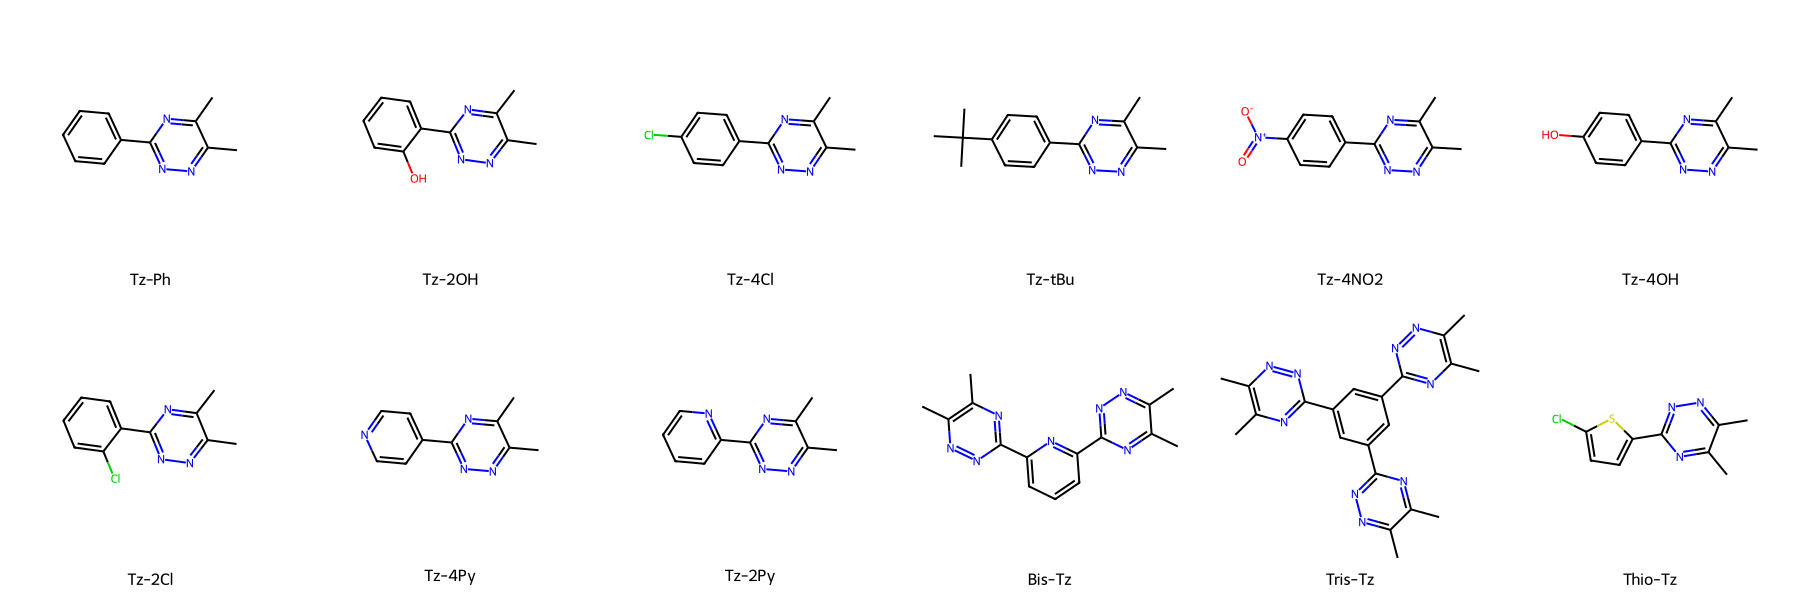

In [11]:
from rdkit.Chem import Draw
molecules_list = [Chem.MolFromSmiles(s) for s in descriptor_df['smiles']]
a = descriptor_df['compound_id'].tolist()

img = Draw.MolsToGridImage(molecules_list, molsPerRow=6, legends = a, subImgSize=(300, 300))

display(img)

In [12]:
from rdkit import Chem
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit.Chem import rdMolDescriptors

descriptor_df["N_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==7
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["O_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==8
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["S_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==16
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

halogens = [9,17,35,53]

descriptor_df["Halogen_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum() in halogens
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["Hetero_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum() not in [1,6]
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["Ring_count"] = descriptor_df["smiles"].apply(
    lambda s:
    rdMolDescriptors.CalcNumRings(
        Chem.MolFromSmiles(s)
    )
)

descriptor_df[["compound_id","N_atoms","O_atoms","S_atoms","Halogen_atoms","Hetero_atoms","Ring_count"]]

,compound_id,N_atoms,O_atoms,S_atoms,Halogen_atoms,Hetero_atoms,Ring_count
0,Tz-Ph,3,0,0,0,3,2
1,Tz-2OH,3,1,0,0,4,2
2,Tz-4Cl,3,0,0,1,4,2
3,Tz-tBu,3,0,0,0,3,2
4,Tz-4NO2,4,2,0,0,6,2
5,Tz-4OH,3,1,0,0,4,2
6,Tz-2Cl,3,0,0,1,4,2
7,Tz-4Py,4,0,0,0,4,2
8,Tz-2Py,4,0,0,0,4,2
9,Bis-Tz,7,0,0,0,7,3


In [13]:
descriptor_df["Priority_Score"] = (
      descriptor_df["HBA"]*2
    + descriptor_df["HBD"]*1
    + descriptor_df["AromaticRings"]*0.5
)
descriptor_df["Priority_Score"] -= (
    abs(descriptor_df["LogP"] - 2.0)
)
descriptor_df

,compound_id,compound_name,smiles,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,N_atoms,O_atoms,S_atoms,Halogen_atoms,Hetero_atoms,Ring_count,Priority_Score
0,Tz-Ph,"3-phenyl-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2,185.23,2.16,38.67,0,3,1,2,3,0,0,0,3,2,6.84
1,Tz-2OH,"3-(2-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2O,201.23,1.86,58.90,1,4,1,2,3,1,0,0,4,2,9.86
2,Tz-4Cl,"3-(4-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(Cl)cc2,219.68,2.81,38.67,0,3,1,2,3,0,0,1,4,2,6.19
3,Tz-tBu,"3-(4-tert-butylphenyl)-5,6-dimethyl-1,2,4-tria...",Cc1nnc(nc1(C))c2ccc(C(C)(C)C)cc2,241.34,3.45,38.67,0,3,1,2,3,0,0,0,3,2,5.55
4,Tz-4NO2,"3-(4-nitrophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc([N+](=O)[O-])cc2,230.23,2.06,81.81,0,5,2,2,4,2,0,0,6,2,10.94
5,Tz-4OH,"3-(4-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(O)cc2,201.23,1.86,58.90,1,4,1,2,3,1,0,0,4,2,9.86
6,Tz-2Cl,"3-(2-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2Cl,219.68,2.81,38.67,0,3,1,2,3,0,0,1,4,2,6.19
7,Tz-4Py,"3-(4-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccncc2,186.22,1.55,51.56,0,4,1,2,4,0,0,0,4,2,8.55
8,Tz-2Py,"3-(2-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ncccc2,186.22,1.55,51.56,0,4,1,2,4,0,0,0,4,2,8.55
9,Bis-Tz,"2,6-bis-(5,6-dimethyl-1,2,4-triazinyl)pyridine",CC1=NC(C2=NC(C3=NC(C)=C(C)N=N3)=CC=C2)=NN=C1C,293.33,2.02,90.23,0,7,2,3,7,0,0,0,7,3,15.48


In [14]:
descriptor_df.to_csv(
    "../results/exp_dataset.csv",
    index=False
)

In [15]:
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import rdFingerprintGenerator

mols = [Chem.MolFromSmiles(s) for s in descriptor_df["smiles"]]

morgan = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fps = [morgan.GetFingerprint(mol) for mol in mols]


mat = []

for i in fps:
    row = []
    for j in fps:
        row.append(TanimotoSimilarity(i, j))
    mat.append(row)

sim_df = pd.DataFrame(
    mat,
    index=descriptor_df["compound_id"],
    columns=descriptor_df["compound_id"]
)

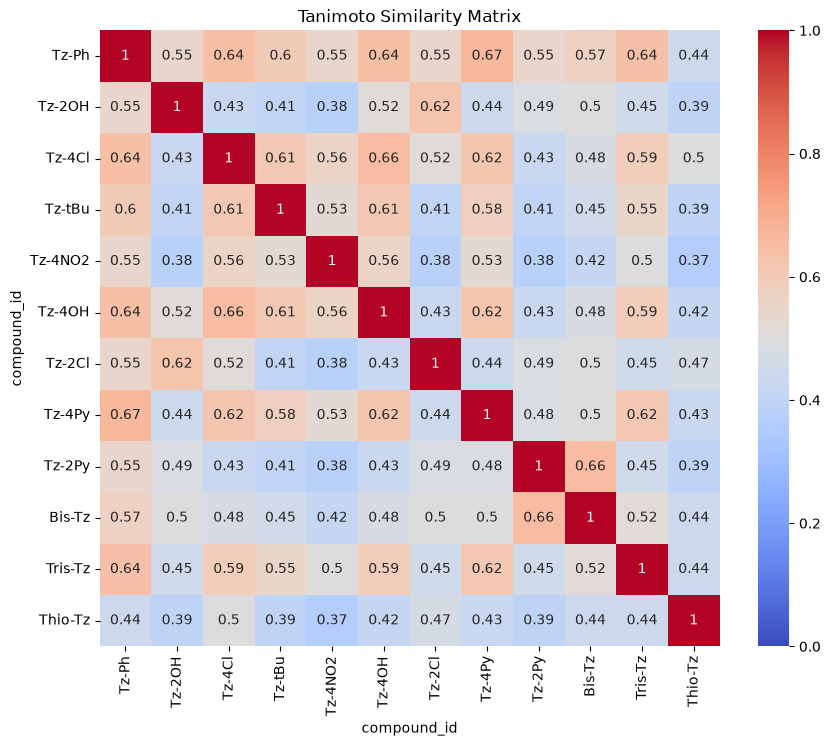

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(sim_df,
            annot=True,
            cmap="coolwarm",    
            vmin=0,            
            vmax=1,            
            center=0.5,)

plt.title("Tanimoto Similarity Matrix")
plt.show()

In [17]:
max_sim = 0  #coz fps range from 0 to 1
pair = ()   # empty set

for i in range(len(fps)):   #suppose len(fps) = 12, loops from 0 to 11
    for j in range(i+1, len(fps)):  #nest loop compares eg: (1,0), (2,0),...and to avoid (0,0),(1,1) coz both will be same molecule
        sim = TanimotoSimilarity(fps[i], fps[j])    # find the similarity values of every i and j

        if sim > max_sim:       #if generated sim greater than max_sim, do the following condition
            max_sim = sim       
            pair = (
                descriptor_df.iloc[i]["compound_id"],       #the row no. of the comp goes into i and their compound id stores in pair
                descriptor_df.iloc[j]["compound_id"]
            )

print("Most similar pair:", pair)
print("Similarity =", round(max_sim,3))

avg_sim = sim_df.mean(axis=1)

avg_sim.sort_values()

Most similar pair: ('Tz-Ph', 'Tz-4Py')
Similarity = 0.667


compound_id
Thio-Tz    0.473948
Tz-4NO2    0.510651
Tz-2Py     0.511978
Tz-2OH     0.514230
Tz-2Cl     0.520687
Bis-Tz     0.543771
Tz-tBu     0.545954
Tris-Tz    0.566929
Tz-4Py     0.577438
Tz-4OH     0.579656
Tz-4Cl     0.586600
Tz-Ph      0.616300
dtype: float64

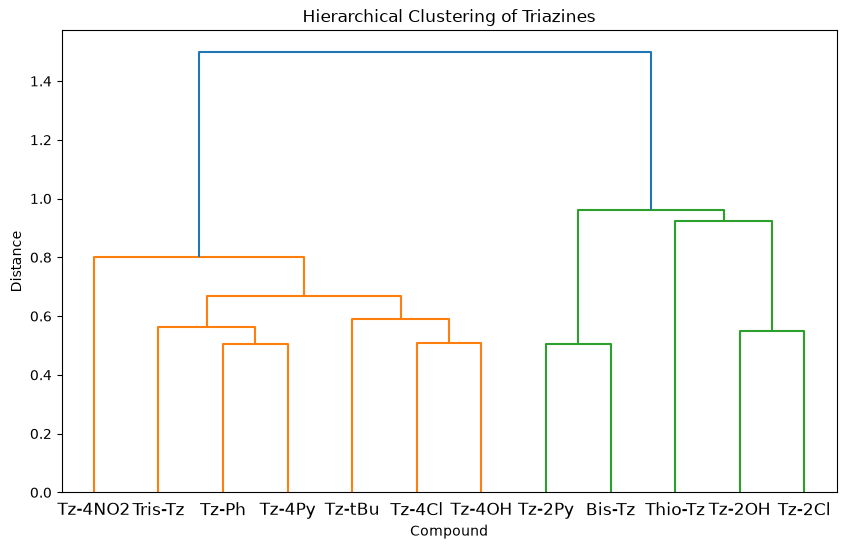

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(sim_df, method='ward')

plt.figure(figsize=(10,6))

dendrogram(
    linked,
    labels=descriptor_df["compound_id"].tolist()
)

plt.title("Hierarchical Clustering of Triazines")
plt.xlabel("Compound")
plt.ylabel("Distance")

plt.show()


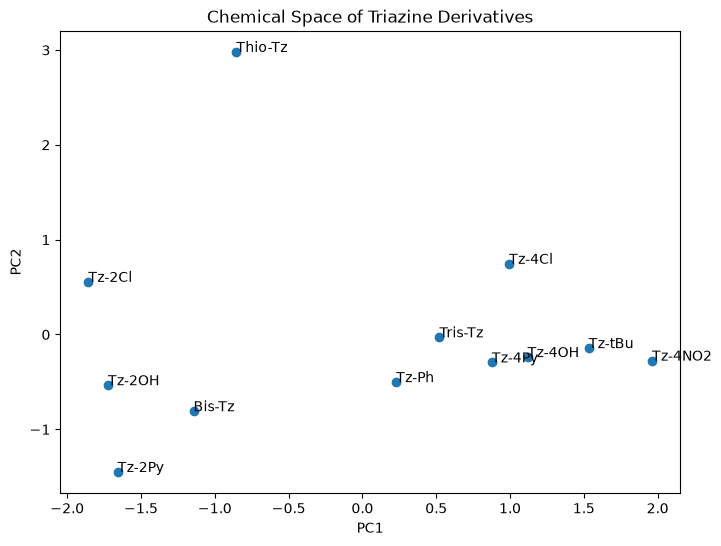

[0.22869637 0.14641794]


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from rdkit.DataStructs import ConvertToNumpyArray

fp_array = []

for fp in fps:
    arr = np.zeros((2048,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    fp_array.append(arr)

fp_array = np.array(fp_array)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(fp_array)
pca_df = descriptor_df.copy()

pca_df["PC1"] = pca_result[:,0]
pca_df["PC2"] = pca_result[:,1]
pca_df[["compound_id","PC1","PC2"]]

plt.figure(figsize=(8,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for i, txt in enumerate(pca_df["compound_id"]):
    plt.annotate(
        txt,
        (pca_df["PC1"][i], pca_df["PC2"][i])
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Chemical Space of Triazine Derivatives")
plt.show()

print(pca.explained_variance_ratio_)